---
<p style="text-align: center;font-size: 2em;font-weight: bold;">
Mini projet 6 - Optimisation
</p>
<p style="text-align: center;font-weight: bold;">
Lukas FERMAUT - Anaïs CORBIERE
</p>


---

# 1. Optimisation à temps final fixé

1. De la même manière, on part de la condition dynamique sur y:
$$\int_{t_k}^{t_{k+1}}\ddot{y}(t)dt=\int_{t_k}^{t_{k+1}}a_y(t)dt$$
Donc:
$$v_y^{k+1}-v_y^{k}=a_y^k\int_{t_k}^{t_{k+1}}(1-s^k(t))dt+a_y^{k+1}\int_{t_k}^{t_{k+1}}(s^k(t))dt$$
D'où:
$$v_y^{k+1}-v_y^{k}=a_y^k\left[t-\frac{t^2-2t_kt}{2\Delta t}\right]_{t_k}^{t_{k+1}}+a_y^{k+1}\left[\frac{t^2-2t_kt}{2\Delta t}\right]_{t_k}^{t_{k+1}}$$

Ainsi avec une identité remarquable:

$$v_y^{k+1}=v_y^{k}+\frac{\Delta t}{2}(a_y^k+a_y^{k+1})$$

Pour trouver la deuxième relation, on intègre la condition dynamique entre $t_k$ et une variable $u$, puis on intègre une deuxième fois selon $u$ entre $t_k$ et $t_{k+1}$. On obtient alors: 

$$h^{k+1}=h^k+v_h^k\Delta t-\frac{(\Delta t)^2}{3}a_h^k+\frac{(\Delta t)^2}{6}a_h^{k+1}


2. Le coût discrétisé correspondant à J est:


$$
\begin{aligned}
J &= \int_0^T \left(a_h(t)^2 + a_y(t)^2\right)\,dt \\
  &= \int_0^T \Big( \big((1 - s^k(t))a_h^k + s^k(t)a_h^{k+1}\big)^2 + \big((1 - s^k(t))a_y^k + s^k(t)a_y^{k+1}\big)^2 \Big)\,dt \\
\end{aligned}
$$

Etudions le terme de gauche:

$$\begin{aligned}
\int_0^T \Big( \big((1 - s^k(t))a_h^k + s^k(t)a_h^{k+1}\big)^2 &= \sum^N_{k=0}\int_{t_k}^{t_{k+1}}\Big((1-\frac{t-t_k}{\Delta t})a_h^k+\frac{t-t_k}{\Delta t}a_h^{k+1}\Big)^2dt \\
&=\sum^N_{k=0}\left[\frac{\Delta t}{3(a_h^{k+1}-a_h^{k})}\Big((1-\frac{t-t_k}{\Delta t})a_h^k+\frac{t-t_k}{\Delta t}a_h^{k+1}\Big)^3\right]^{t_{k+1}}_{t_k} \\
&=\sum^N_{k=0}\frac{\Delta t}{3}\Big((a_h^{k+1})^2+a_h^ka_h^{k+1}+(a_h^k)^2\Big)


\end{aligned}
$$
On a alors, par le même calcul pour le terme de droite, J en fonction des variables $(a_h^k)$ et $(a_y^k)$ ainsi que du temps de vol T:

$$J=\sum^N_{k=0}\frac{T}{3N}\Big((a_h^{k+1})^2+a_h^ka_h^{k+1}+(a_h^k)^2+(a_y^{k+1})^2+a_y^ka_y^{k+1}+(a_y^k)^2\Big)


3. Le problème discrétisé complet est:

4. Implémentation du code

In [4]:
import numpy as np  
import casadi as ca
g=9.81 #m/s^2   

def solve(T,N,h0,vh0,y0,vy0):
    dt=T/N
    n=N+1
    ah=ca.SX.sym('ah', n)
    ay=ca.SX.sym('ay', n)
    h=ca.SX.sym('h', n)
    vh=ca.SX.sym('vh', n)
    y=ca.SX.sym('y', n)
    vy=ca.SX.sym('vy', n)   #on met toutes les variables
    x=ca.vertcat(ah, ay, h, vh, y, vy)
    J=0
    for i in range(N):   #on calcule J
        J+=(dt/3)*(ah[i+1]**2+ay[i+1]**2+ah[i]**2+ay[i]**2+ah[i+1]*ah[i]+ay[i+1]*ay[i])
    t=[]
    lbg=[]
    ubg=[]

    for i in range(N):  #Dynamique 
        t.append(vh[i+1]-(vh[i]-g*dt+dt/2*(ah[i]+ah[i+1])))
        t.append(h[i+1]-(h[i]+vh[i]*dt-0.5*g*dt**2+(dt**2/3)*ah[i]+(dt**2/6)*ah[i+1]))
        t.append(vy[i+1]-(vy[i]+(dt/2)*(ay[i]+ay[i+1])))
        t.append(y[i+1]-(y[i]+vy[i]*dt+(dt**2/3)*ay[i]+(dt**2/6)*ay[i+1]))
        lbg+=[0]*4
        ubg+=[0]*4
    
    for i in range(n):  #Conditions sur limites d'accélération
        t.append(ah[i]**2 + ay[i]**2)
        lbg.append(0)
        ubg.append(a_max**2)

        ###

    lbx = [0]*n +[-a_max]*n+[-ca.inf]*(4*n)
    ubx = [a_max]*n+[a_max]*n+[ca.inf]*(4*n)


    lbx[2*n]=ubx[2*n]=h0 #conditions initiales
    lbx[3*n]=ubx[3*n]=vh0
    lbx[4*n]=ubx[4*n]=y0
    lbx[5*n]=ubx[5*n]=vy0

    lbx[2*n+N]=ubx[2*n+N]=0 #conditions finales
    lbx[3*n+N]=ubx[3*n+N]=0
    lbx[4*n+N]=ubx[4*n+N]=0
    lbx[5*n+N]=ubx[5*n+N]=0

    nlp = {'x': x, 'f': J, 'g': ca.vertcat(*t)}
    solver = ca.nlpsol('s', 'ipopt', nlp)
    
    x0 = np.zeros(6*n)
    x0[:N+1] = g
    sol =  solver(
        x0 = x0,
        lbx= lbx,
        ubx= ubx,
        lbg= lbg,
        ubg= ubg,
    )
    
    res = sol['x'].full().flatten() #à comprendre ligne faite à l'IA
    J_opt = float(sol['f'])
    return res, J_opt


5. 2 nvlles inegalités sur les fonctions

In [5]:
#On rajoute dans le code précédent à ###

for i in range(n):
    t.append(y[i]-h[i]*np.tan(gamma))
    lbg.append(-ca.inf)
    ubg.append(0)
    t.append(y[i]+h[i]*np.tan(gamma))
    lbg.append(0)
    ubg.append(ca.inf)
    t.append(ay[i]-ah[i]*np.tan(thetam))
    lbg.append(-ca.inf)
    ubg.append(0)
    t.append(ay[i]+ah[i]*np.tan(thetam))
    lbg.append(0)
    ubg.append(ca.inf)


#Anais pour explication du code: On crée toutes les variables dans casadi qu'on crée dans un vecteur on fait nos petits calculs q1 et 2
#Puis les inégalités sur les fonctions on code avec lbg et upg (lower et upper)
#les conditions sur les variables on fait avec upx et lbx
#les conditions initiales et finales les égalités on met plus petit et plus grand que leur valeur
#puis globalement jai copié le truc du tp 3

NameError: name 'n' is not defined

6.

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:      202
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      202

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.6244000e+02 1.19e+03 9.78e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

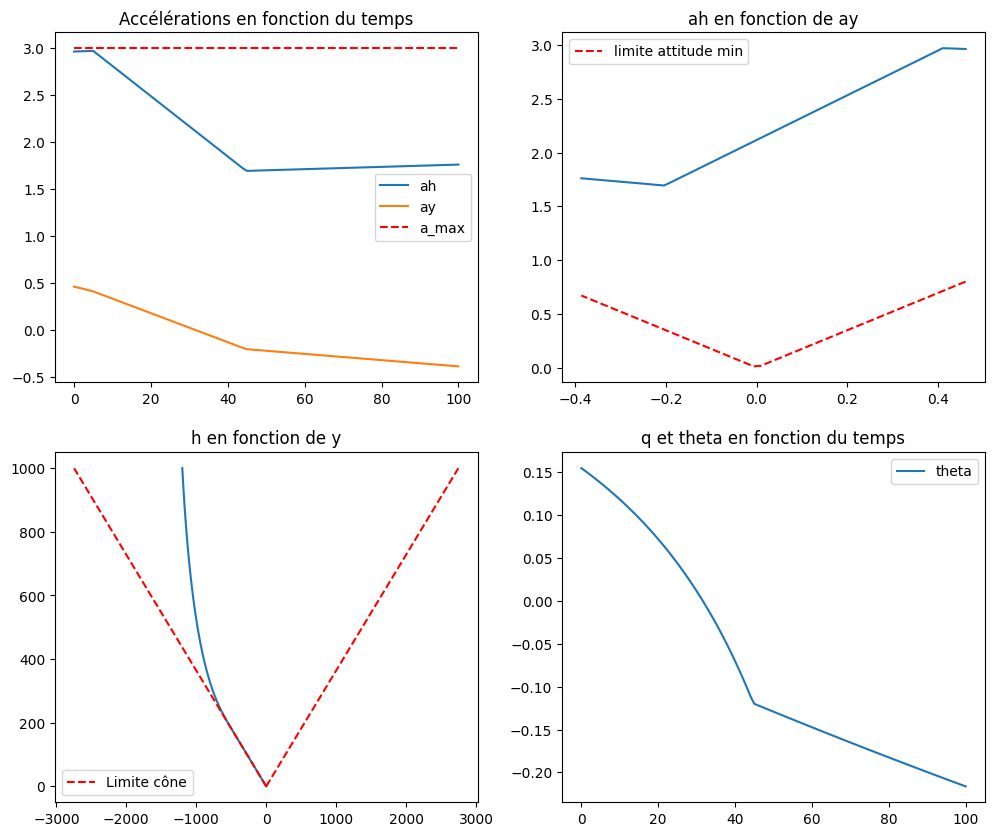

h0= 1000 vh0= -41 y0= -1200 vy0= 10


438.20414080787

In [ ]:
import numpy as np  
import casadi as ca
import matplotlib.pyplot as plt
g=9.81 #m/s^2   

h0 = 1000 #m
vh0= -41 #m/s
y0 = -1200 #m
vy0= 10 #m/s
a_max = 3  #m/s2
η = 3050 #m/s
m = 15000 #kg
g = 1.62 #m/s2
thetam = np.deg2rad(30) #◦
gamma = np.deg2rad(70) #◦
N = 100
T=100

def solve(T,N,h0,vh0,y0,vy0):
    dt=T/N
    n=N+1
    ah=ca.SX.sym('ah', n)
    ay=ca.SX.sym('ay', n)
    h=ca.SX.sym('h', n)
    vh=ca.SX.sym('vh', n)
    y=ca.SX.sym('y', n)
    vy=ca.SX.sym('vy', n)   #on met toutes les variables
    x=ca.vertcat(ah, ay, h, vh, y, vy)
    J=0
    for i in range(N):   #on calcule J
        J+=(dt/3)*(ah[i+1]**2+ay[i+1]**2+ah[i]**2+ay[i]**2+ah[i+1]*ah[i]+ay[i+1]*ay[i])
    t=[]
    lbg=[]
    ubg=[]

    for i in range(N):  #Dynamique 
        t.append(vh[i+1]-(vh[i]-g*dt+dt/2*(ah[i]+ah[i+1])))
        t.append(h[i+1]-(h[i]+vh[i]*dt-0.5*g*dt**2+(dt**2/3)*ah[i]+(dt**2/6)*ah[i+1]))
        t.append(vy[i+1]-(vy[i]+(dt/2)*(ay[i]+ay[i+1])))
        t.append(y[i+1]-(y[i]+vy[i]*dt+(dt**2/3)*ay[i]+(dt**2/6)*ay[i+1]))
        lbg+=[0]*4
        ubg+=[0]*4
        
    
    for i in range(n):  #Conditions sur limites d'accélération
        t.append(ah[i]**2 + ay[i]**2)
        lbg.append(0)
        ubg.append(a_max**2)
        t.append(y[i]-h[i]*np.tan(gamma))
        lbg.append(-ca.inf)
        ubg.append(0)
        t.append(y[i]+h[i]*np.tan(gamma))
        lbg.append(0)
        ubg.append(ca.inf)
        t.append(ay[i]-ah[i]*np.tan(thetam))
        lbg.append(-ca.inf)
        ubg.append(0)
        t.append(ay[i]+ah[i]*np.tan(thetam))
        lbg.append(0)
        ubg.append(ca.inf)
        ###

    lbx = [0]*n +[-a_max]*n+[-ca.inf]*(4*n)
    ubx = [a_max]*n+[a_max]*n+[ca.inf]*(4*n)


    lbx[2*n]=ubx[2*n]=h0 #conditions initiales
    lbx[3*n]=ubx[3*n]=vh0
    lbx[4*n]=ubx[4*n]=y0
    lbx[5*n]=ubx[5*n]=vy0

    lbx[2*n+N]=ubx[2*n+N]=0 #conditions finales
    lbx[3*n+N]=ubx[3*n+N]=0
    lbx[4*n+N]=ubx[4*n+N]=0
    lbx[5*n+N]=ubx[5*n+N]=0

    nlp = {'x': x, 'f': J, 'g': ca.vertcat(*t)}
    solver = ca.nlpsol('s', 'ipopt', nlp)
    
    x0 = np.zeros(6*n)
    x0[:N+1] = g
    sol =  solver(
        x0 = x0,
        lbx= lbx,
        ubx= ubx,
        lbg= lbg,
        ubg= ubg,
    )
    
    res = sol['x'].full().flatten()
    J_opt = float(sol['f'])

    return res, J_opt


def tracer(T,res,J_opt):
    t=np.linspace(0,T,N+1)
    ah=res[:N+1]
    ay=res[N+1:2*(N+1)] 
    h=res[2*(N+1):3*(N+1)]
    vh=res[3*(N+1):4*(N+1)]
    y=res[4*(N+1):5*(N+1)]
    vy=res[5*(N+1):6*(N+1)]


    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    #a

    axs[0,0].plot(t,ah,label='ah')
    axs[0,0].plot(t,ay,label='ay')
    axs[0,0].plot(t,[a_max]*len(t), 'r--', label='a_max')
    axs[0,0].set_title('Accélérations en fonction du temps')
    axs[0,0].legend()

    #b

    axs[0,1].plot(ay,ah)
    axs[0,1].set_title('ah en fonction de ay')
    axs[0,1].plot(ay,np.abs(ay)/np.tan(thetam),'r--', label='limite attitude min')
    axs[0,1].legend()
    #c

    axs[1,0].plot(y,h)
    axs[1,0].set_title('h en fonction de y')
    hl=np.linspace(0,h0,100)
    axs[1,0].plot(hl*np.tan(gamma),hl,'r--',label='Limite cône')
    axs[1,0].plot(-hl*np.tan(gamma),hl,'r--')
    axs[1,0].legend()

    #d

    q=m/η*np.sqrt(ah**2+ay**2)
    theta=np.arctan(ay/ah)
    axs[1,1].plot(t,q,label='q')
    axs[1,1].plot(t,theta,label='theta')
    axs[1,1].set_title('q et theta en fonction du temps')
    axs[1,1].legend()

    plt.show()
    print('h0=', h0, 'vh0=', vh0, 'y0=', y0, 'vy0=', vy0)
    return J_opt

res, J=solve(T,N,h0,vh0,y0,vy0)
tracer(T,res,J)

7.

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:      202
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      202

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3122000e+02 2.72e+03 9.75e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

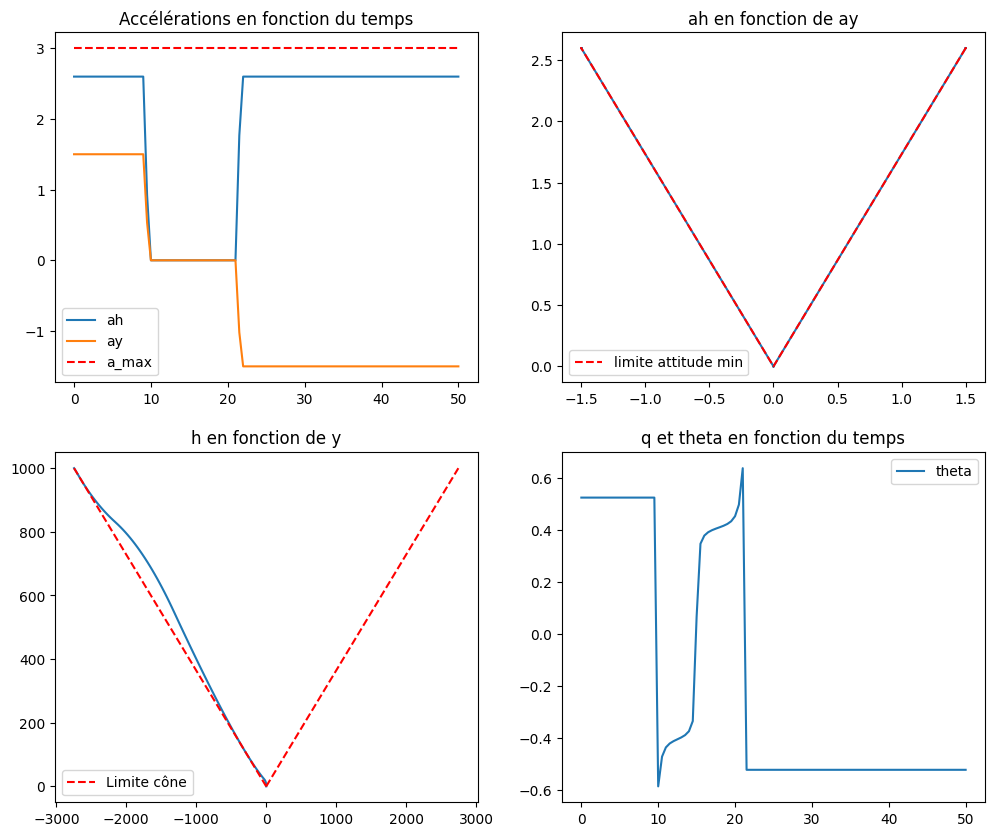

h0= 1000 vh0= -40 y0= -2747.4774194546217 vy0= 45


339.32165962399563

In [27]:
h0 = 1000 #m
vh0= -40 #m/s
y0 = -h0*np.tan(gamma) #m
vy0= 45#m/s
T=50
res,J=solve(T,N,h0,vh0,y0,vy0)
tracer(T,res,J)

8.

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:      202
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      202

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.8732000e+01 1.21e+03 9.75e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

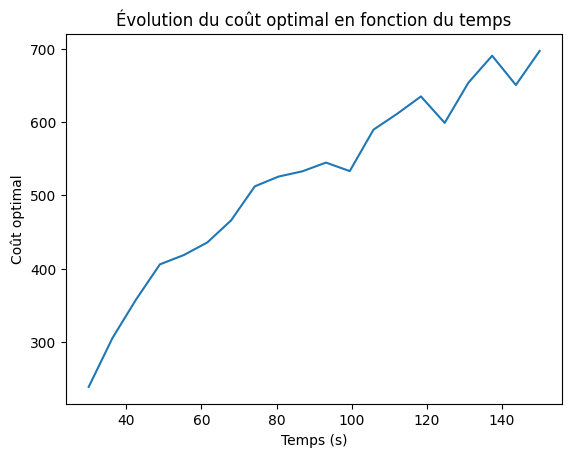

In [32]:
h0 = 1000 #m
vh0= -40 #m/s
y0 = -1200 #m
vy0= vh0*np.tan(thetam) #m/s
T=np.linspace(30,150,20)
J=[]
for t in T:
    res,J1=solve(t,N,h0,vh0,y0,vy0)
    J.append(J1)

plt.plot(T,J)
plt.xlabel('Temps (s)')
plt.ylabel('Coût optimal')
plt.title('Évolution du coût optimal en fonction du temps')
plt.show()


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1790
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      402

Total number of variables............................:      598
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:      202
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      202

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.6244000e+02 1.19e+03 9.78e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

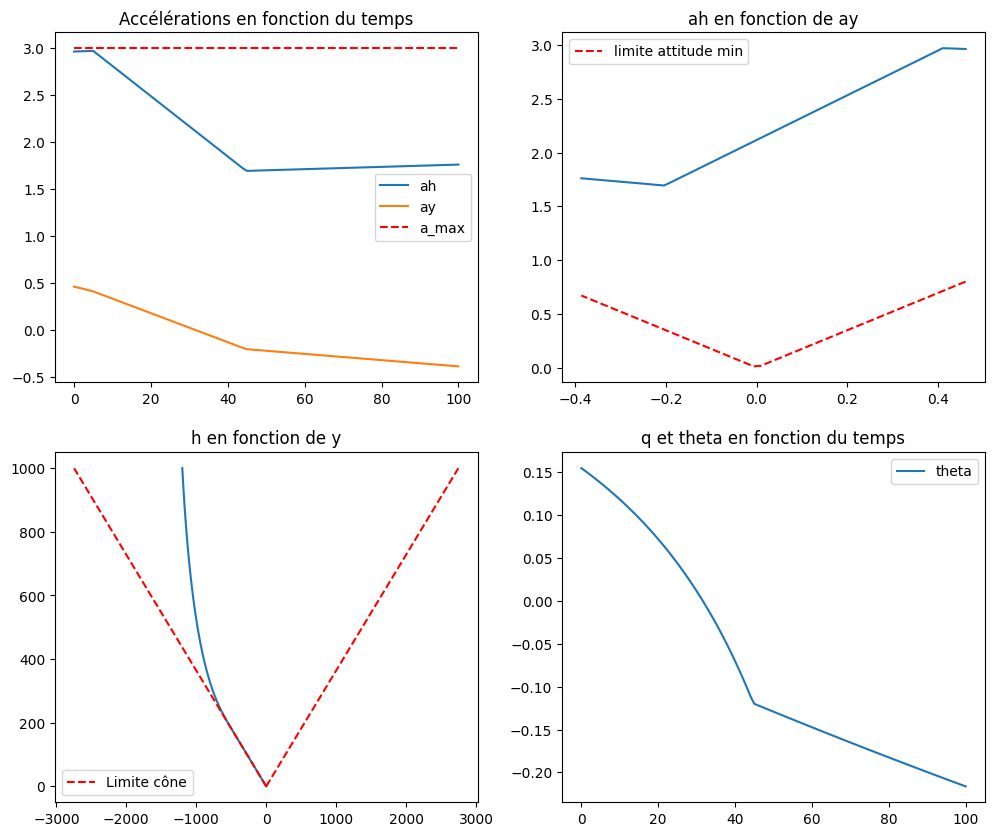

h0= 1000 vh0= -41 y0= -1200 vy0= 10
438.20414080787


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     2190
Number of nonzeros in inequality constraint Jacobian.:     1002
Number of nonzeros in Lagrangian Hessian.............:      803

Total number of variables............................:      599
                     variables with only lower bounds:        1
                variables with lower and upper bounds:      202
                     variables with only upper bounds:        0
Total number of equality constraints.................:      400
Total number of inequality constraints...............:      505
        inequality constraints with only lower bounds:      202
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:      202

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.6243974e-02 1.20e+03 1.62e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

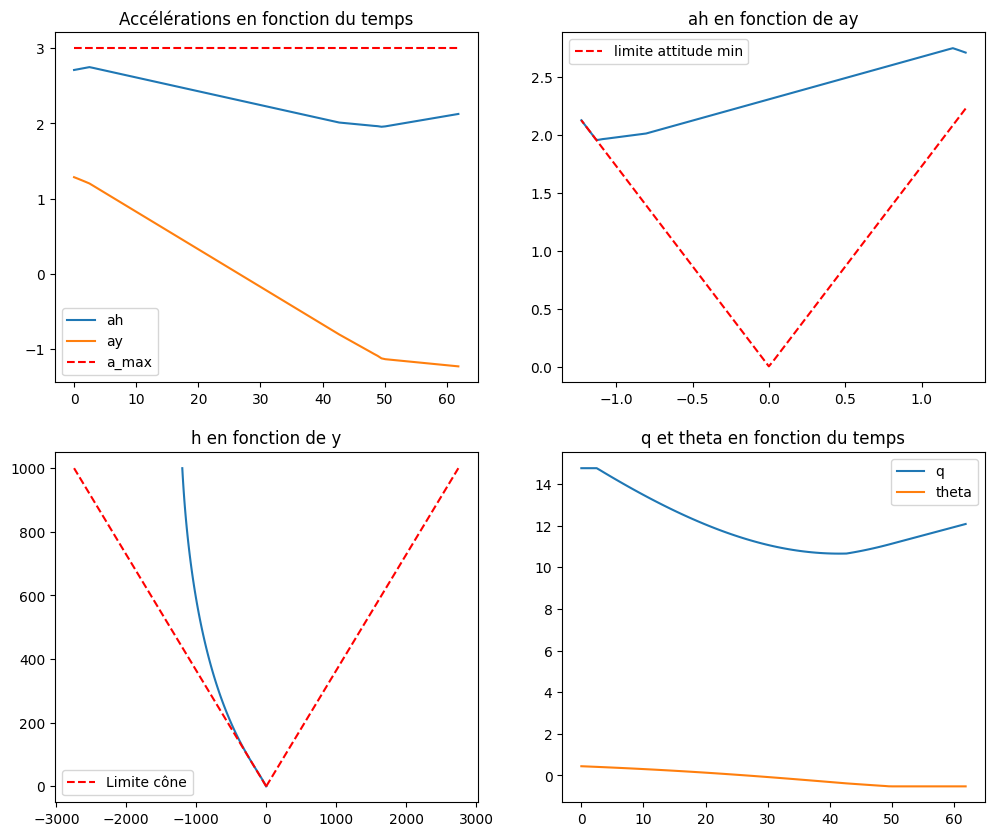

h0= 1000 vh0= -41 y0= -1200 vy0= 10


In [38]:
h0 = 1000 #m
vh0= -41 #m/s
y0 = -1200 #m
vy0= 10 #m/s

def solve2(N,h0,vh0,y0,vy0):
    T=ca.SX.sym('T')
    dt=T/N
    n=N+1
    ah=ca.SX.sym('ah', n)
    ay=ca.SX.sym('ay', n)
    h=ca.SX.sym('h', n)
    vh=ca.SX.sym('vh', n)
    y=ca.SX.sym('y', n)
    vy=ca.SX.sym('vy', n)   #on met toutes les variables
    x=ca.vertcat(ah, ay, h, vh, y, vy,T)
    J=0
    for i in range(N):   #on calcule J
        J+=(dt/3)*(ah[i+1]**2+ay[i+1]**2+ah[i]**2+ay[i]**2+ah[i+1]*ah[i]+ay[i+1]*ay[i])
    t=[]
    lbg=[]
    ubg=[]

    for i in range(N):  #Dynamique 
        t.append(vh[i+1]-(vh[i]-g*dt+dt/2*(ah[i]+ah[i+1])))
        t.append(h[i+1]-(h[i]+vh[i]*dt-0.5*g*dt**2+(dt**2/3)*ah[i]+(dt**2/6)*ah[i+1]))
        t.append(vy[i+1]-(vy[i]+(dt/2)*(ay[i]+ay[i+1])))
        t.append(y[i+1]-(y[i]+vy[i]*dt+(dt**2/3)*ay[i]+(dt**2/6)*ay[i+1]))
        lbg+=[0]*4
        ubg+=[0]*4
        
    
    for i in range(n):  #Conditions sur limites d'accélération
        t.append(ah[i]**2 + ay[i]**2)
        lbg.append(0)
        ubg.append(a_max**2)
        t.append(y[i]-h[i]*np.tan(gamma))
        lbg.append(-ca.inf)
        ubg.append(0)
        t.append(y[i]+h[i]*np.tan(gamma))
        lbg.append(0)
        ubg.append(ca.inf)
        t.append(ay[i]-ah[i]*np.tan(thetam))
        lbg.append(-ca.inf)
        ubg.append(0)
        t.append(ay[i]+ah[i]*np.tan(thetam))
        lbg.append(0)
        ubg.append(ca.inf)
        ###

    lbx = [0]*n +[-a_max]*n+[-ca.inf]*(4*n)+[0]
    ubx = [a_max]*n+[a_max]*n+[ca.inf]*(4*n)+[ca.inf]


    lbx[2*n]=ubx[2*n]=h0 #conditions initiales
    lbx[3*n]=ubx[3*n]=vh0
    lbx[4*n]=ubx[4*n]=y0
    lbx[5*n]=ubx[5*n]=vy0

    lbx[2*n+N]=ubx[2*n+N]=0 #conditions finales
    lbx[3*n+N]=ubx[3*n+N]=0
    lbx[4*n+N]=ubx[4*n+N]=0
    lbx[5*n+N]=ubx[5*n+N]=0

    nlp = {'x': x, 'f': J, 'g': ca.vertcat(*t)}
    solver = ca.nlpsol('s', 'ipopt', nlp)
    
    x0 = np.zeros(6*n+1)
    x0[:N+1] = g
    sol =  solver(
        x0 = x0,
        lbx= lbx,
        ubx= ubx,
        lbg= lbg,
        ubg= ubg,
    )
    
    res = sol['x'].full().flatten()
    J_opt = float(sol['f'])

    return res, J_opt


def tracer2(res,J_opt):
    ah=res[:N+1]
    ay=res[N+1:2*(N+1)] 
    h=res[2*(N+1):3*(N+1)]
    vh=res[3*(N+1):4*(N+1)]
    y=res[4*(N+1):5*(N+1)]
    vy=res[5*(N+1):6*(N+1)]
    T=res[6*(N+1)]
    t=np.linspace(0,T,N+1)


    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    #a

    axs[0,0].plot(t,ah,label='ah')
    axs[0,0].plot(t,ay,label='ay')
    axs[0,0].plot(t,[a_max]*len(t), 'r--', label='a_max')
    axs[0,0].set_title('Accélérations en fonction du temps')
    axs[0,0].legend()

    #b

    axs[0,1].plot(ay,ah)
    axs[0,1].set_title('ah en fonction de ay')
    axs[0,1].plot(ay,np.abs(ay)/np.tan(thetam),'r--', label='limite attitude min')
    axs[0,1].legend()
    #c

    axs[1,0].plot(y,h)
    axs[1,0].set_title('h en fonction de y')
    hl=np.linspace(0,h0,100)
    axs[1,0].plot(hl*np.tan(gamma),hl,'r--',label='Limite cône')
    axs[1,0].plot(-hl*np.tan(gamma),hl,'r--')
    axs[1,0].legend()

    #d

    q=m/η*np.sqrt(ah**2+ay**2)
    theta=np.arctan(ay/ah)
    axs[1,1].plot(t,q,label='q')
    axs[1,1].plot(t,theta,label='theta')
    axs[1,1].set_title('q et theta en fonction du temps')
    axs[1,1].legend()

    plt.show()
    print('h0=', h0, 'vh0=', vh0, 'y0=', y0, 'vy0=', vy0)

res, J=solve2(N,h0,vh0,y0,vy0)
tracer2(res,J)